<a href="https://colab.research.google.com/github/anuragpandey4/ml/blob/main/decision_tree_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
titanic = sns.load_dataset("titanic")

In [3]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
features = ["pclass", "sex", "fare", "embarked", "age"]
target = ["survived"]

In [5]:
# missing data
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [6]:
titanic.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


In [7]:
# encode
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [8]:
X = titanic[features]
y = titanic[target]

In [9]:
X.head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
# Decision Tree Model - no pruning
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model. fit(X_train, y_train)

DecisionTreeClassifier()

In [26]:
from sklearn.metrics import accuracy_score
y_pred = model. predict (X_test)

print("accuracy: ", accuracy_score(y_test,y_pred))

accuracy:  0.7597765363128491


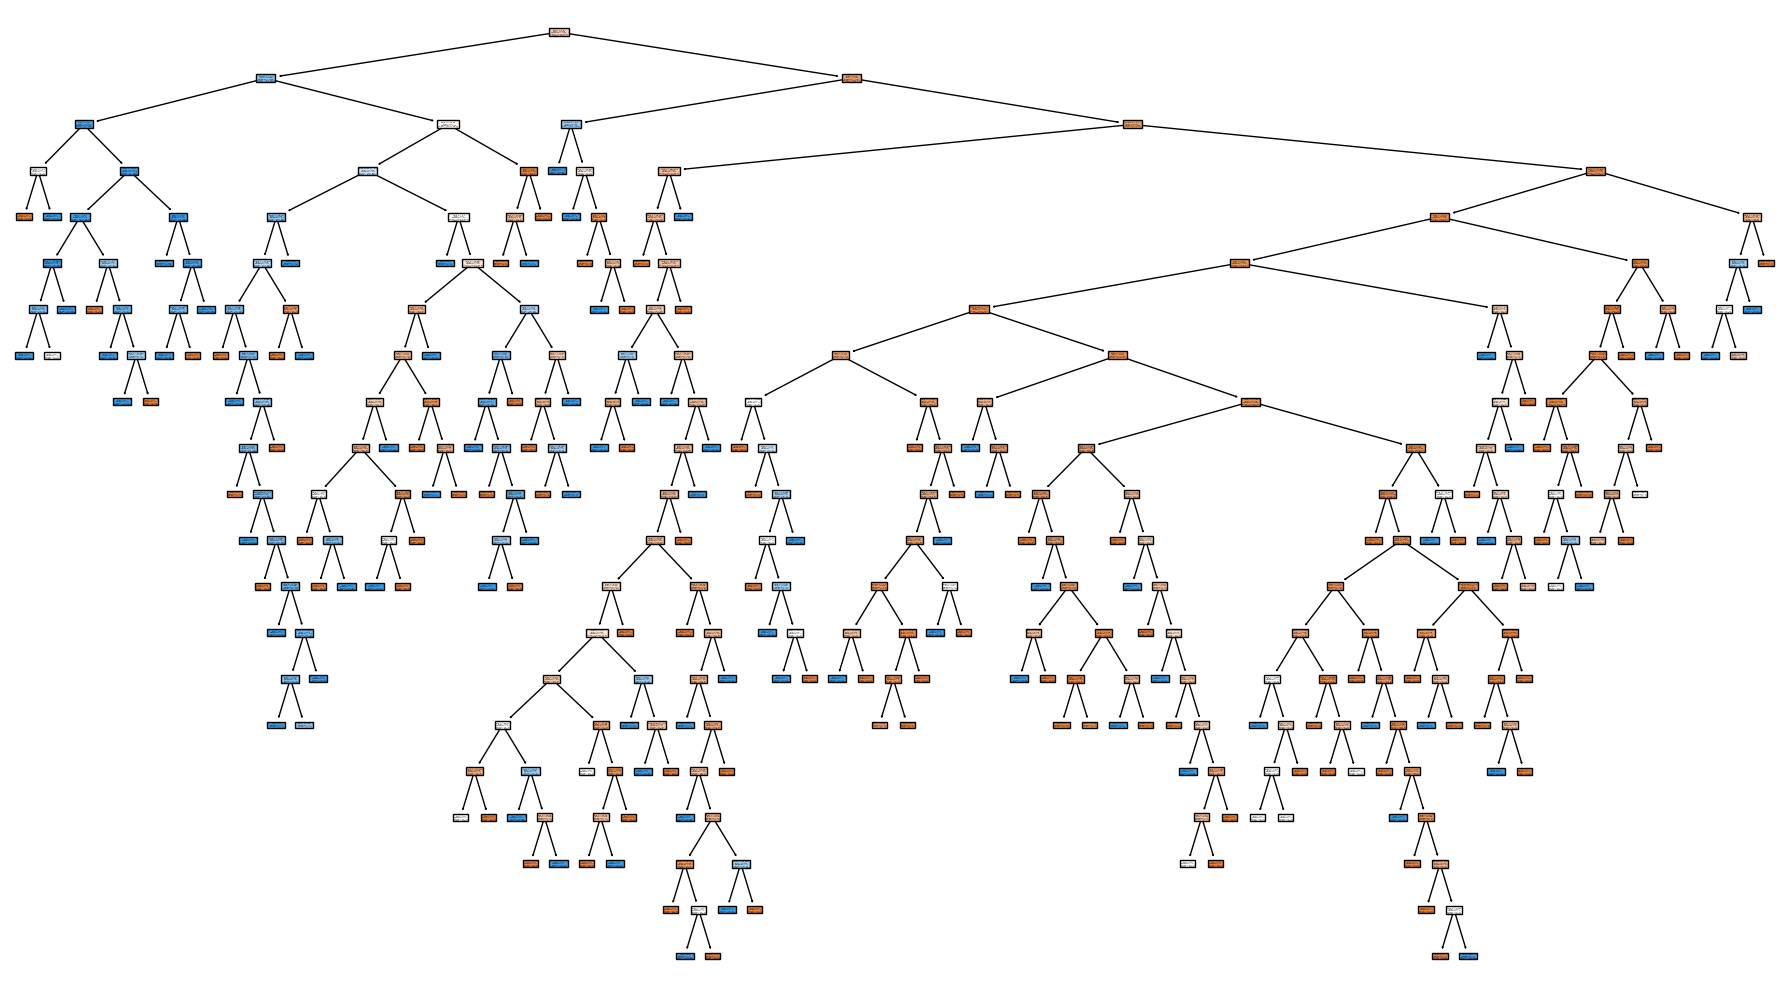

In [27]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18, 10))
plot_tree(
  model,
  feature_names=X.columns,
  class_names=["Died", "Survived"],
  filled=True
)

plt.tight_layout()
plt.show()

# Decision Tree with Prepuning

In [28]:
max_depths = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for depth in max_depths:
  model = DecisionTreeClassifier(max_depth =  depth)
  model.fit(X_train, y_train)

  acc = model.score(X_test, y_test)
  print(f"for depth={depth}, accuracy={acc}")

for depth=2, accuracy=0.7653631284916201
for depth=3, accuracy=0.7988826815642458
for depth=4, accuracy=0.7988826815642458
for depth=5, accuracy=0.7988826815642458
for depth=6, accuracy=0.8044692737430168
for depth=7, accuracy=0.7988826815642458
for depth=8, accuracy=0.7932960893854749
for depth=9, accuracy=0.7877094972067039
for depth=10, accuracy=0.7988826815642458


In [29]:
min_samples_splits = [5, 10, 15, 20, 25, 30]

for split in min_samples_splits:
  model = DecisionTreeClassifier(max_depth = 6, min_samples_split = split)
  model.fit(X_train, y_train)

  acc = model.score(X_test, y_test)
  print(f"for sample split={split}, accuracy={acc}")

for sample split=5, accuracy=0.8044692737430168
for sample split=10, accuracy=0.8100558659217877
for sample split=15, accuracy=0.8044692737430168
for sample split=20, accuracy=0.8044692737430168
for sample split=25, accuracy=0.7988826815642458
for sample split=30, accuracy=0.7877094972067039
